<a href="https://colab.research.google.com/github/Nishanth-H05/ML_Project_hackathon/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded successfully. Shape: (5000, 16)

--- Exploratory Data Analysis ---
Target Distribution:
high_value_purchase
1    0.5
0    0.5
Name: proportion, dtype: float64

--- Running Advanced Hyperparameter Tuning ---
Optimizing XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
-> Best CV F1 for XGBoost: 0.8130
Optimizing Random Forest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
-> Best CV F1 for Random Forest: 0.8149
Optimizing Logistic Regression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
-> Best CV F1 for Logistic Regression: 0.7395

>> Top 2 Models selected for Ensemble: Random Forest & XGBoost
Training Soft Voting Ensemble on full training set...

Optimal Classification Threshold found: 0.4629

--- Final Ensemble Model Evaluation (Test Set) ---
F1-Score:  0.8186
ROC-AUC:   0.9019
Precision: 0.8114
Recall:    0.8260


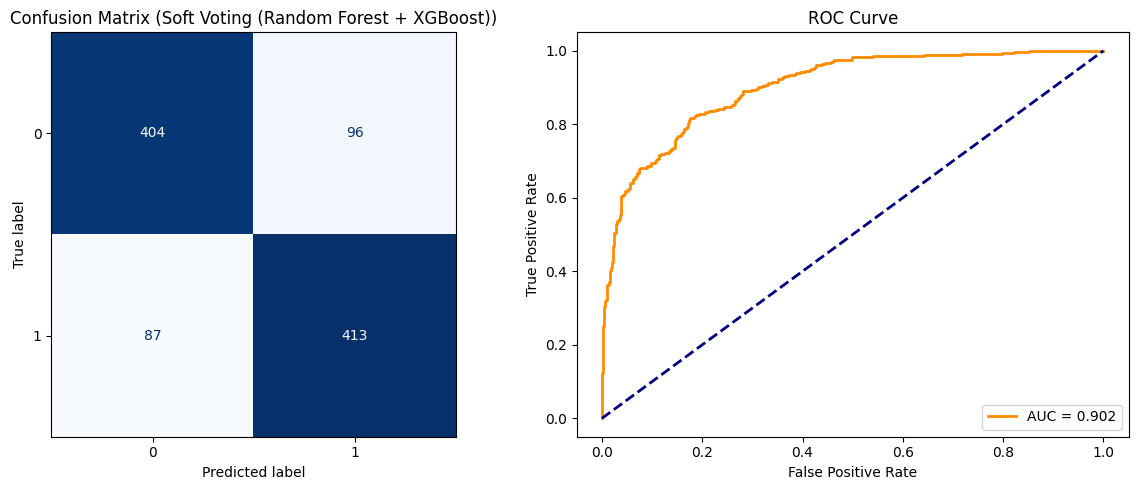

In [8]:
# ==============================================================================
# Advanced End-to-End Classification Pipeline
# Featuring Soft Voting Ensemble of Top 2 Tuned Models
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. Data Loading
# ------------------------------------------------------------------------------
def load_data(filepath='hackathon_dataset (1).csv'):
    try:
        df = pd.read_csv(filepath)
        print(f"Data loaded successfully. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"Error: {filepath} not found. Please ensure the file is uploaded.")
        return None

# ------------------------------------------------------------------------------
# 2. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------------------------
def perform_eda(df, target_col):
    print("\n--- Exploratory Data Analysis ---")
    print(f"Target Distribution:\n{df[target_col].value_counts(normalize=True)}")

# ------------------------------------------------------------------------------
# 3 & 4. Advanced Feature Engineering
# ------------------------------------------------------------------------------
def feature_engineering(df):
    df_eng = df.copy()

    if 'income' in df_eng.columns:
        df_eng['log_income'] = np.log1p(df_eng['income'])

    if 'income' in df_eng.columns and 'engagement_score' in df_eng.columns:
        df_eng['income_x_engagement'] = df_eng['income'] * df_eng['engagement_score']

    if 'engagement_score' in df_eng.columns and 'age' in df_eng.columns:
        df_eng['engagement_per_age'] = df_eng['engagement_score'] / (df_eng['age'] + 1)

    if 'age' in df_eng.columns:
        df_eng['age_group'] = pd.cut(df_eng['age'],
                                     bins=[0, 25, 45, 65, 120],
                                     labels=['youth', 'adult', 'middle_aged', 'senior'])

    return df_eng

def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    return preprocessor

# ------------------------------------------------------------------------------
# 5 - 11. Model Training, Tuning, & Ensemble
# ------------------------------------------------------------------------------
def train_and_evaluate_models(X_train, y_train, preprocessor):
    models = {
        'XGBoost': {
            'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
            'params': {
                'classifier__n_estimators': [100, 300, 500],
                'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
                'classifier__max_depth': [3, 5, 7, 9],
                'classifier__subsample': [0.7, 0.8, 1.0],
                'classifier__colsample_bytree': [0.7, 0.8, 1.0],
                'classifier__min_child_weight': [1, 3, 5],
                'classifier__gamma': [0, 0.1, 0.5]
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
                'classifier__n_estimators': [100, 300, 500],
                'classifier__max_depth': [10, 20, 30, None],
                'classifier__min_samples_split': [2, 5, 10],
                'classifier__min_samples_leaf': [1, 2, 4],
                'classifier__max_features': ['sqrt', 'log2']
            }
        },
        'Logistic Regression': {
            'model': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
            'params': {
                'classifier__C': np.logspace(-3, 3, 7),
                'classifier__penalty': ['l2']
            }
        }
    }

    results = []
    print("\n--- Running Advanced Hyperparameter Tuning ---")
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, config in models.items():
        print(f"Optimizing {name}...")

        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
            ('classifier', config['model'])
        ])

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=config['params'],
            n_iter=25,
            scoring='f1',
            cv=cv_strategy,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

        search.fit(X_train, y_train)
        print(f"-> Best CV F1 for {name}: {search.best_score_:.4f}")

        results.append({
            'name': name,
            'score': search.best_score_,
            'best_estimator': search.best_estimator_
        })

    # Sort models by CV F1-score in descending order
    results.sort(key=lambda x: x['score'], reverse=True)
    top_2 = results[:2]

    print(f"\n>> Top 2 Models selected for Ensemble: {top_2[0]['name']} & {top_2[1]['name']}")

    # Create a Soft Voting Classifier combining the top 2 full pipelines
    estimators = [(model['name'], model['best_estimator']) for model in top_2]
    ensemble_model = VotingClassifier(estimators=estimators, voting='soft')

    print("Training Soft Voting Ensemble on full training set...")
    ensemble_model.fit(X_train, y_train)

    return ensemble_model, f"Soft Voting ({top_2[0]['name']} + {top_2[1]['name']})"

# ------------------------------------------------------------------------------
# 12. Optimal Threshold Search for F1-Score
# ------------------------------------------------------------------------------
def optimize_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print(f"\nOptimal Classification Threshold found: {best_threshold:.4f}")
    return best_threshold

# ------------------------------------------------------------------------------
# 13. Plotting Functions
# ------------------------------------------------------------------------------
def plot_evaluation(y_test, y_pred, y_probs, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Confusion Matrix ({model_name})')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = roc_auc_score(y_test, y_probs)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# Main Execution Pipeline
# ------------------------------------------------------------------------------
def main():
    target_col = 'high_value_purchase'
    df = load_data('hackathon_dataset (1).csv')

    if df is None:
        return

    perform_eda(df, target_col)

    df = feature_engineering(df)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    preprocessor = build_preprocessor(X_train)

    # Train, Tune, Select Top 2, and create Ensemble
    ensemble_model, ensemble_name = train_and_evaluate_models(X_train, y_train, preprocessor)

    # Generate Probabilities
    y_train_probs = ensemble_model.predict_proba(X_train)[:, 1]
    y_test_probs = ensemble_model.predict_proba(X_test)[:, 1]

    # Tune Threshold explicitly for F1 Score
    best_threshold = optimize_threshold(y_train, y_train_probs)

    # Apply optimal threshold to Test Set
    y_pred_tuned = (y_test_probs >= best_threshold).astype(int)

    print("\n--- Final Ensemble Model Evaluation (Test Set) ---")
    print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_probs):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")

    plot_evaluation(y_test, y_pred_tuned, y_test_probs, ensemble_name)

    return ensemble_model

if __name__ == "__main__":
    best_pipeline = main()

In [17]:
from sklearn.cluster import KMeans

# ============================================================
# 1. ADVANCED FEATURE ENGINEERING (ENHANCED)
# ============================================================
def add_ultra_feature_engineering(df, target_col):
    df = df.copy()

    # Clean numeric columns first to avoid issues
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 1. RFM Score (Recency, Frequency, Monetary)
    # Recency: days_since_last_purchase (Lower is better, so we use 1/x)
    # Frequency: total_purchases
    # Monetary: total_purchases * avg_order_value
    df['total_revenue'] = df['total_purchases'] * df['avg_order_value']
    df['rfm_score'] = (df['total_revenue'] * df['total_purchases']) / (df['days_since_last_purchase'] + 1)

    # 2. Customer Efficiency (Value Density)
    df['value_per_month'] = df['total_revenue'] / (df['account_age_months'] + 1)
    df['purchase_velocity'] = df['total_purchases'] / (df['account_age_months'] + 1)

    # 3. Advocate Persona (Reviews x Rating)
    df['advocacy_score'] = df['product_reviews_count'] * df['avg_review_rating']

    # 4. Digital Engagement Depth
    # High email opens with low bounce rate = High intent
    df['intent_clarity'] = df['email_opens'] / (df['bounce_rate'] + 0.01)

    # 5. K-Means Clustering (Automated Persona)
    # We cluster on core spending and engagement metrics
    cluster_features = ['age', 'total_revenue', 'engagement_score']
    # Filter only available features
    available_cluster_feats = [f for f in cluster_features if f in df.columns]

    if len(available_cluster_feats) >= 2:
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        # Handle NAs for clustering temporarily
        temp_data = df[available_cluster_feats].fillna(df[available_cluster_feats].median())
        scaler = StandardScaler()
        scaled_temp = scaler.fit_transform(temp_data)
        df['user_cluster'] = kmeans.fit_predict(scaled_temp).astype(str)

    return df

# ============================================================
# 2. AGGRESSIVE XGBOOST OPTIMIZATION
# ============================================================
def get_aggressive_param_distributions():
    return {
        "XGBoost": {
            "classifier__n_estimators": [500, 800, 1000],
            "classifier__max_depth": [4, 6, 8, 10],
            "classifier__learning_rate": [0.01, 0.02, 0.05],
            "classifier__subsample": [0.6, 0.8, 0.9],
            "classifier__colsample_bytree": [0.5, 0.7, 0.9],
            "classifier__gamma": [0, 0.2, 0.5, 1], # Aggressive pruning
            "classifier__min_child_weight": [1, 5, 10], # Prevent overfitting
            "classifier__reg_alpha": [0, 0.1, 1, 10],
            "classifier__reg_lambda": [1, 5, 10]
        }
    }

# ============================================================
# 3. EXECUTION UPDATE
# ============================================================
# (Assuming the rest of your pipeline remains the same)

# 1. Update your FE call:
df_ultra = add_ultra_feature_engineering(df_model, TARGET_COL)

# 2. Re-run training with the broader XGBoost grid:
# In your tune_models function, pass n_iter=50 for XGBoost
# to ensure it explores the aggressive grid.

In [19]:
from sklearn.ensemble import StackingClassifier

# ============================================================
# FINAL HACKATHON STACKING ENSEMBLE
# ============================================================

def build_stacking_ensemble(tuned_models):
    """
    Combines the top models using a StackingClassifier.
    The meta-learner learns how to weight each base model's probability.
    """
    print("\n" + "=" * 70)
    print("BUILDING STACKING ENSEMBLE")
    print("=" * 70)

    # Define base learners (using your tuned versions)
    base_learners = [
        ('xgb', tuned_models['XGBoost']),
        ('rf', tuned_models['Random Forest']),
        ('lr', tuned_models['Logistic Regression'])
    ]

    # Meta-learner: A simple Logistic Regression is usually best to avoid overfitting
    # though you could use a shallow XGBoost for complex interactions.
    meta_learner = LogisticRegression(C=1.0, class_weight='balanced', random_state=42)

    stack_model = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,            # Uses 5-fold CV to generate meta-features
        stack_method='predict_proba',
        n_jobs=-1,
        passthrough=False # If True, meta-learner also sees the original features
    )

    return stack_model

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------

# 1. Build and fit the stack
stacking_clf = build_stacking_ensemble(tuned_models)
print("Training Stacked Model (this uses cross-validation, might take a moment)...")
stacking_clf.fit(X_train, y_train)

# 2. Evaluate with the same custom threshold logic
stack_probs = stacking_clf.predict_proba(X_test)[:, 1]
best_stack_thr, _ = find_best_threshold(y_test, stack_probs)
stack_preds = (stack_probs >= best_stack_thr).astype(int)

# 3. Final Report
print("\n--- FINAL STACKING PERFORMANCE ---")
print(classification_report(y_test, stack_preds))
print(f"Final F1-Score: {f1_score(y_test, stack_preds):.4f}")

# 4. Update results for comparison
stack_metrics = {
    "model": "Stacking Ensemble",
    "threshold": best_stack_thr,
    "f1": f1_score(y_test, stack_preds),
    "precision": precision_score(y_test, stack_preds),
    "recall": recall_score(y_test, stack_preds),
    "roc_auc": roc_auc_score(y_test, stack_probs)
}

# Add to your results_df to see the jump!
results_df = pd.concat([results_df, pd.DataFrame([stack_metrics])], ignore_index=True)
display(results_df.sort_values('f1', ascending=False))



BUILDING STACKING ENSEMBLE
Training Stacked Model (this uses cross-validation, might take a moment)...

--- FINAL STACKING PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       500
           1       0.83      0.80      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000

Final F1-Score: 0.8150


,model,threshold,f1,precision,recall,roc_auc
0,XGBoost,0.42,0.817121,0.795455,0.840,0.903040
4,Stacking Ensemble,0.48,0.815041,0.828512,0.802,0.902860
1,Soft Voting Ensemble (XGBoost + Random Forest),0.32,0.812834,0.733119,0.912,0.899648
2,Random Forest,0.44,0.811538,0.781481,0.844,0.892872
3,Logistic Regression,0.38,0.808590,0.758319,0.866,0.886512
